# Dataset Comparison: HESE12 vs FinalTopology vs BDT-split

This notebook compares three data samples:
- **HESE12**: `/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/data/HESE12/WithoutDeepCore/`
- **FinalTopology**: `datasets/flavor_globalfit/hese/split/data_HESE_pass2_v3_FinalTopology/`
- **BDT-split**: `datasets/flavor_globalfit/hese/split/data_HESE_pass2_v3/mcd-.../bdt1_0.333333_bdt2_0.366667_length_10/`

The FinalTopology and BDT-split datasets require a `reco_energy > 60 TeV` cut.

The overlap analysis is **restricted to events present in HESE12** (all topology bins combined). Extra events in the new datasets are analysed separately.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

## Paths

In [30]:
HESE12_DIR = '/data/ana/Diffuse/GlobalFit_Flavor/NNMFit_Datasets/data/HESE12/WithoutDeepCore/'
FT_DIR = ('/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/'
          'flavor_globalfit/hese/split/data_HESE_pass2_v3_FinalTopology/')
BDT_DIR = ('/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/'
           'flavor_globalfit/hese/split/data_HESE_pass2_v3/'
           'mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/'
           'bdt1_0.333333_bdt2_0.366667_length_10/')

ENERGY_CUT = 60e3  # GeV

## Load all datasets

In [31]:
# HESE12 (energy cut already applied upstream)
hese12_track  = pd.read_hdf(HESE12_DIR + 'data_HESE12_Tracks/dataset_HESE12_Tracks.hdf')
hese12_casc   = pd.read_hdf(HESE12_DIR + 'data_HESE12_Cascades/dataset_HESE12_Cascades.hdf')
hese12_double = pd.read_hdf(HESE12_DIR + 'data_HESE12_DoubleCascades/dataset_HESE12_DoubleCascades.hdf')

# FinalTopology — apply energy cut
ft_track_raw  = pd.read_parquet(FT_DIR + 'dataset_data_HESE_pass2_v3_track.parquet')
ft_casc_raw   = pd.read_parquet(FT_DIR + 'dataset_data_HESE_pass2_v3_cascade.parquet')
ft_double_raw = pd.read_parquet(FT_DIR + 'dataset_data_HESE_pass2_v3_double.parquet')

ft_track  = ft_track_raw[ft_track_raw['reco_energy'] > ENERGY_CUT].copy()
ft_casc   = ft_casc_raw[ft_casc_raw['reco_energy'] > ENERGY_CUT].copy()
ft_double = ft_double_raw[ft_double_raw['reco_energy'] > ENERGY_CUT].copy()

# BDT-split — apply energy cut
bdt_track_raw  = pd.read_parquet(BDT_DIR + 'dataset_data_HESE_pass2_v3_track.parquet')
bdt_casc_raw   = pd.read_parquet(BDT_DIR + 'dataset_data_HESE_pass2_v3_cascade.parquet')
bdt_double_raw = pd.read_parquet(BDT_DIR + 'dataset_data_HESE_pass2_v3_double.parquet')

bdt_track  = bdt_track_raw[bdt_track_raw['reco_energy'] > ENERGY_CUT].copy()
bdt_casc   = bdt_casc_raw[bdt_casc_raw['reco_energy'] > ENERGY_CUT].copy()
bdt_double = bdt_double_raw[bdt_double_raw['reco_energy'] > ENERGY_CUT].copy()

print(f'HESE12:        tracks={len(hese12_track):3d}  cascades={len(hese12_casc):3d}  doubles={len(hese12_double):2d}  total={len(hese12_track)+len(hese12_casc)+len(hese12_double)}')
print(f'FinalTopology: tracks={len(ft_track):3d}  cascades={len(ft_casc):3d}  doubles={len(ft_double):2d}  total={len(ft_track)+len(ft_casc)+len(ft_double)}  (before cut: {len(ft_track_raw)}/{len(ft_casc_raw)}/{len(ft_double_raw)})')
print(f'BDT-split:     tracks={len(bdt_track):3d}  cascades={len(bdt_casc):3d}  doubles={len(bdt_double):2d}  total={len(bdt_track)+len(bdt_casc)+len(bdt_double)}  (before cut: {len(bdt_track_raw)}/{len(bdt_casc_raw)}/{len(bdt_double_raw)})')

HESE12:        tracks= 28  cascades= 64  doubles= 5  total=97
FinalTopology: tracks= 29  cascades= 78  doubles= 3  total=110  (before cut: 51/134/3)
BDT-split:     tracks= 39  cascades= 70  doubles= 1  total=110  (before cut: 64/122/2)


## Event sets

Events are identified by their 3-level index `(run_id, event_id, subevent_id)`. The overlap analysis is restricted to events present in HESE12.

In [32]:
def to_set(df):
    return set(df.index.tolist())

h12_t_ids = to_set(hese12_track)
h12_c_ids = to_set(hese12_casc)
h12_d_ids = to_set(hese12_double)
h12_all   = h12_t_ids | h12_c_ids | h12_d_ids

ft_t_ids  = to_set(ft_track)
ft_c_ids  = to_set(ft_casc)
ft_d_ids  = to_set(ft_double)
ft_all    = ft_t_ids | ft_c_ids | ft_d_ids

bdt_t_ids = to_set(bdt_track)
bdt_c_ids = to_set(bdt_casc)
bdt_d_ids = to_set(bdt_double)
bdt_all   = bdt_t_ids | bdt_c_ids | bdt_d_ids

# Events not in HESE12
ft_extra  = ft_all  - h12_all
bdt_extra = bdt_all - h12_all

print(f'Total unique events — HESE12: {len(h12_all)}, FT: {len(ft_all)}, BDT: {len(bdt_all)}')
print(f'Extra events in FT  (not in HESE12): {len(ft_extra)}')
print(f'Extra events in BDT (not in HESE12): {len(bdt_extra)}')

Total unique events — HESE12: 97, FT: 110, BDT: 110
Extra events in FT  (not in HESE12): 15
Extra events in BDT (not in HESE12): 15


## Per-event classification — HESE12 events only

For each event in HESE12, report which topology bin it lands in in FT and BDT.

In [33]:
def topology_in(eid, t_ids, c_ids, d_ids):
    if eid in t_ids:  return 'track'
    if eid in c_ids:  return 'cascade'
    if eid in d_ids:  return 'double'
    return 'MISSING'

def get_from_h12(eid, col):
    for df in (hese12_track, hese12_casc, hese12_double):
        if eid in to_set(df):
            return float(df.loc[eid, col])

rows = []
for eid in h12_all:
    rows.append({
        'run':      eid[0],
        'event_id': eid[1],
        'sub':      eid[2],
        'reco_energy [TeV]': get_from_h12(eid, 'reco_energy') / 1e3,
        'HESE12':  topology_in(eid, h12_t_ids, h12_c_ids, h12_d_ids),
        'FT':      topology_in(eid, ft_t_ids,  ft_c_ids,  ft_d_ids),
        'BDT':     topology_in(eid, bdt_t_ids, bdt_c_ids, bdt_d_ids),
    })

full_table = pd.DataFrame(rows).sort_values(['HESE12', 'reco_energy [TeV]']).reset_index(drop=True)
print(full_table.to_string(index=False))

   run  event_id  sub  reco_energy [TeV]  HESE12      FT     BDT
124571  17513088    0          64.767084 cascade cascade cascade
126099  12931336    0          65.039794 cascade cascade cascade
119214   8606380    0          66.535803 cascade cascade cascade
124244   7608824    0          67.126795 cascade cascade cascade
125914  75630389    0          70.976905 cascade MISSING MISSING
136348  65788242    0          74.087283 cascade cascade   track
128695  52259779    0          74.954974 cascade cascade cascade
127339  64954567    0          77.015646 cascade cascade cascade
123867  11659459    0          79.091666 cascade cascade   track
132992  53918721    0          80.492331 cascade cascade cascade
123217  66529770    0          81.540838 cascade cascade cascade
136673   4249774    0          83.197762 cascade cascade cascade
118283   9445773    0          86.855820 cascade cascade cascade
118178  66452255    0          87.462563 cascade cascade cascade
129316  30230768    0    

## Track overlap percentages — HESE12 events only

In [34]:
def topo_breakdown(source_ids, t_ids, c_ids, d_ids, all_ids, name):
    n = len(source_ids)
    breakdown = {
        'track':   source_ids & t_ids,
        'cascade': source_ids & c_ids,
        'double':  source_ids & d_ids,
        'MISSING': source_ids - all_ids,
    }
    print(f'  In {name}:')
    for label, s in breakdown.items():
        print(f'    {label:8s}: {len(s):3d}  ({100*len(s)/n:.1f}%)')
    return breakdown

print(f'=== HESE12 tracks: {len(h12_t_ids)} events ===')
topo_breakdown(h12_t_ids, ft_t_ids,  ft_c_ids,  ft_d_ids,  ft_all,  'FinalTopology')
topo_breakdown(h12_t_ids, bdt_t_ids, bdt_c_ids, bdt_d_ids, bdt_all, 'BDT-split')

print(f'\n=== HESE12 cascades: {len(h12_c_ids)} events ===')
topo_breakdown(h12_c_ids, ft_t_ids,  ft_c_ids,  ft_d_ids,  ft_all,  'FinalTopology')
topo_breakdown(h12_c_ids, bdt_t_ids, bdt_c_ids, bdt_d_ids, bdt_all, 'BDT-split')

print(f'\n=== HESE12 doubles: {len(h12_d_ids)} events ===')
topo_breakdown(h12_d_ids, ft_t_ids,  ft_c_ids,  ft_d_ids,  ft_all,  'FinalTopology')
topo_breakdown(h12_d_ids, bdt_t_ids, bdt_c_ids, bdt_d_ids, bdt_all, 'BDT-split')

=== HESE12 tracks: 28 events ===
  In FinalTopology:
    track   :  23  (82.1%)
    cascade :   4  (14.3%)
    double  :   0  (0.0%)
    MISSING :   1  (3.6%)
  In BDT-split:
    track   :  25  (89.3%)
    cascade :   2  (7.1%)
    double  :   0  (0.0%)
    MISSING :   1  (3.6%)

=== HESE12 cascades: 64 events ===
  In FinalTopology:
    track   :   0  (0.0%)
    cascade :  61  (95.3%)
    double  :   2  (3.1%)
    MISSING :   1  (1.6%)
  In BDT-split:
    track   :   7  (10.9%)
    cascade :  56  (87.5%)
    double  :   0  (0.0%)
    MISSING :   1  (1.6%)

=== HESE12 doubles: 5 events ===
  In FinalTopology:
    track   :   1  (20.0%)
    cascade :   3  (60.0%)
    double  :   1  (20.0%)
    MISSING :   0  (0.0%)
  In BDT-split:
    track   :   1  (20.0%)
    cascade :   3  (60.0%)
    double  :   1  (20.0%)
    MISSING :   0  (0.0%)


{'track': {(116528, 52433389, 0)},
 'cascade': {(125979, 54250116, 0),
  (134004, 76376513, 0),
  (135136, 69399950, 0)},
 'double': {(126283, 47286594, 0)},
 'MISSING': set()}

## Track overlap — Venn diagram (HESE12 events only)

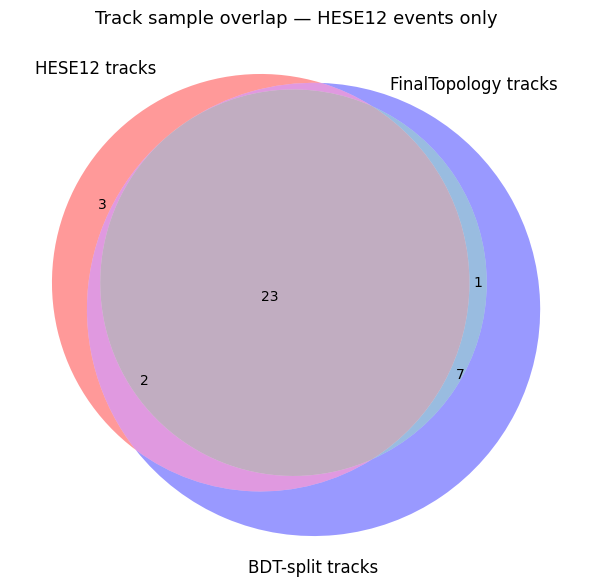

In [36]:
# Restrict FT and BDT track sets to HESE12 events only
ft_t_h12  = ft_t_ids  & h12_all
bdt_t_h12 = bdt_t_ids & h12_all

# venn3_unweighted draws equal-sized circles so labels sit correctly
# even when the exclusive regions are very small slices
fig, ax = plt.subplots(figsize=(7, 6))
v = venn3(
    [h12_t_ids, ft_t_h12, bdt_t_h12],
    set_labels=('HESE12 tracks', 'FinalTopology tracks', 'BDT-split tracks'),
    ax=ax,
)
ax.set_title('Track sample overlap — HESE12 events only', fontsize=13)
plt.tight_layout()
plt.savefig('track_venn.pdf', bbox_inches='tight')
plt.show()

## Extra events in FinalTopology and BDT-split not present in HESE12

In [37]:
def extra_events_table(extra_ids, t_ids, c_ids, d_ids, t_df, c_df, d_df, label):
    extra_t = extra_ids & t_ids
    extra_c = extra_ids & c_ids
    extra_d = extra_ids & d_ids
    n = len(extra_ids)
    print(f'=== Extra events in {label} (not in HESE12): {n} total ===')
    print(f'  track:   {len(extra_t):3d}  ({100*len(extra_t)/n:.1f}%)')
    print(f'  cascade: {len(extra_c):3d}  ({100*len(extra_c)/n:.1f}%)')
    print(f'  double:  {len(extra_d):3d}  ({100*len(extra_d)/n:.1f}%)')
    rows = []
    for topo, ids, df in [('track', extra_t, t_df), ('cascade', extra_c, c_df), ('double', extra_d, d_df)]:
        for eid in ids:
            rows.append({
                'topology':  topo,
                'run':       eid[0],
                'event_id':  eid[1],
                'sub':       eid[2],
                'reco_energy [TeV]': float(df.loc[eid, 'reco_energy']) / 1e3,
                'reco_dir [rad]':    float(df.loc[eid, 'reco_dir']),
            })
    df_out = pd.DataFrame(rows).sort_values(['topology', 'reco_energy [TeV]']).reset_index(drop=True)
    display(df_out)

extra_events_table(ft_extra,  ft_t_ids,  ft_c_ids,  ft_d_ids,  ft_track,  ft_casc,  ft_double,  'FinalTopology')
print()
extra_events_table(bdt_extra, bdt_t_ids, bdt_c_ids, bdt_d_ids, bdt_track, bdt_casc, bdt_double, 'BDT-split')

=== Extra events in FinalTopology (not in HESE12): 15 total ===
  track:     5  (33.3%)
  cascade:  10  (66.7%)
  double:    0  (0.0%)


,topology,run,event_id,sub,reco_energy [TeV],reco_dir [rad]
0,cascade,137527,43987982,0,62.338806,2.458553
1,cascade,137167,67425471,0,63.889094,2.213706
2,cascade,138069,72184188,0,64.450687,2.956980
3,cascade,137891,38931474,0,66.978347,2.715403
4,cascade,137930,36941090,0,73.436089,1.677533
5,cascade,138035,55730330,0,78.404665,1.550966
6,cascade,137845,43811235,0,98.998283,0.435673
7,cascade,137489,30229466,0,107.491038,2.412633
8,cascade,138065,72143074,0,409.014982,0.986253
9,cascade,125826,470241,0,416.499031,1.711151



=== Extra events in BDT-split (not in HESE12): 15 total ===
  track:     6  (40.0%)
  cascade:   9  (60.0%)
  double:    0  (0.0%)


,topology,run,event_id,sub,reco_energy [TeV],reco_dir [rad]
0,cascade,137527,43987982,0,62.338806,2.458553
1,cascade,137167,67425471,0,63.889094,2.213706
2,cascade,138069,72184188,0,64.450687,2.956980
3,cascade,137891,38931474,0,66.978347,2.715403
4,cascade,137930,36941090,0,73.436089,1.677533
5,cascade,138035,55730330,0,78.404665,1.550966
6,cascade,137489,30229466,0,107.491038,2.412633
7,cascade,138065,72143074,0,409.014982,0.986253
8,cascade,125826,470241,0,416.499031,1.711151
9,track,121947,7181486,0,74.496777,0.876333


## Energy distributions — tracks (HESE12 events only)

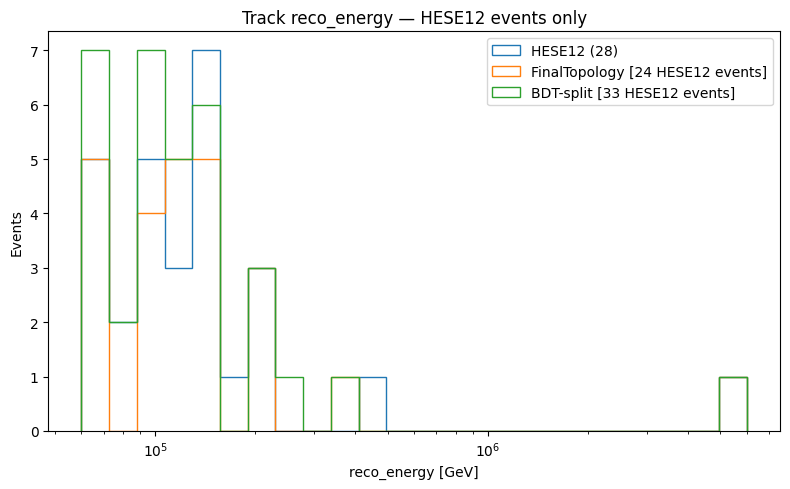

In [38]:
# Restrict FT and BDT to HESE12 events that land in the track bin
ft_track_h12  = ft_track[ft_track.index.isin(h12_all)]
bdt_track_h12 = bdt_track[bdt_track.index.isin(h12_all)]

bins = np.logspace(np.log10(60e3), np.log10(6e6), 25)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(hese12_track['reco_energy'],  bins=bins, histtype='step', lw=2, label=f'HESE12 ({len(hese12_track)})')
ax.hist(ft_track_h12['reco_energy'],  bins=bins, histtype='step', lw=2, label=f'FinalTopology [{len(ft_track_h12)} HESE12 events]')
ax.hist(bdt_track_h12['reco_energy'], bins=bins, histtype='step', lw=2, label=f'BDT-split [{len(bdt_track_h12)} HESE12 events]')
ax.set_xscale('log')
ax.set_xlabel('reco_energy [GeV]')
ax.set_ylabel('Events')
ax.set_title('Track reco_energy — HESE12 events only')
ax.legend()
plt.tight_layout()
plt.savefig('track_energy_comparison.pdf', bbox_inches='tight')
plt.show()

## Zenith distributions — tracks (HESE12 events only)

`reco_dir` is the zenith angle in radians (0 = down-going, π = up-going).

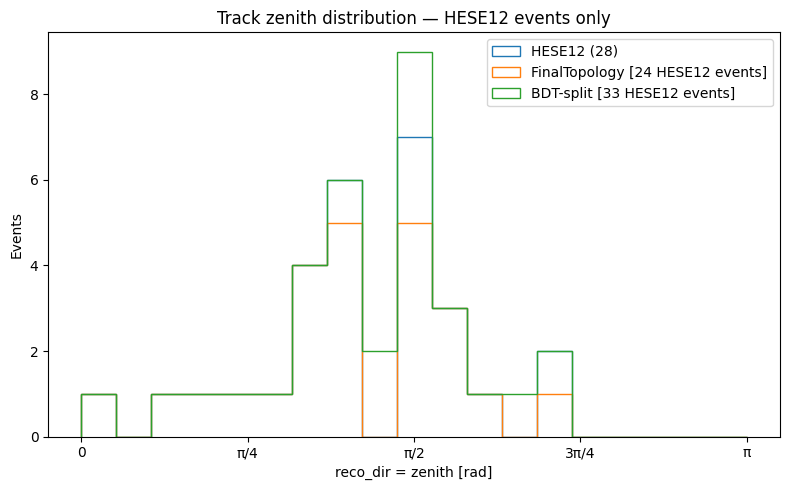

In [39]:
bins_zen = np.linspace(0, np.pi, 20)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(hese12_track['reco_dir'],  bins=bins_zen, histtype='step', lw=2, label=f'HESE12 ({len(hese12_track)})')
ax.hist(ft_track_h12['reco_dir'],  bins=bins_zen, histtype='step', lw=2, label=f'FinalTopology [{len(ft_track_h12)} HESE12 events]')
ax.hist(bdt_track_h12['reco_dir'], bins=bins_zen, histtype='step', lw=2, label=f'BDT-split [{len(bdt_track_h12)} HESE12 events]')
ax.set_xlabel('reco_dir = zenith [rad]')
ax.set_ylabel('Events')
ax.set_title('Track zenith distribution — HESE12 events only')
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels(['0', 'π/4', 'π/2', '3π/4', 'π'])
ax.legend()
plt.tight_layout()
plt.savefig('track_zenith_comparison.pdf', bbox_inches='tight')
plt.show()

## Zenith distributions — all topologies (HESE12 events only)

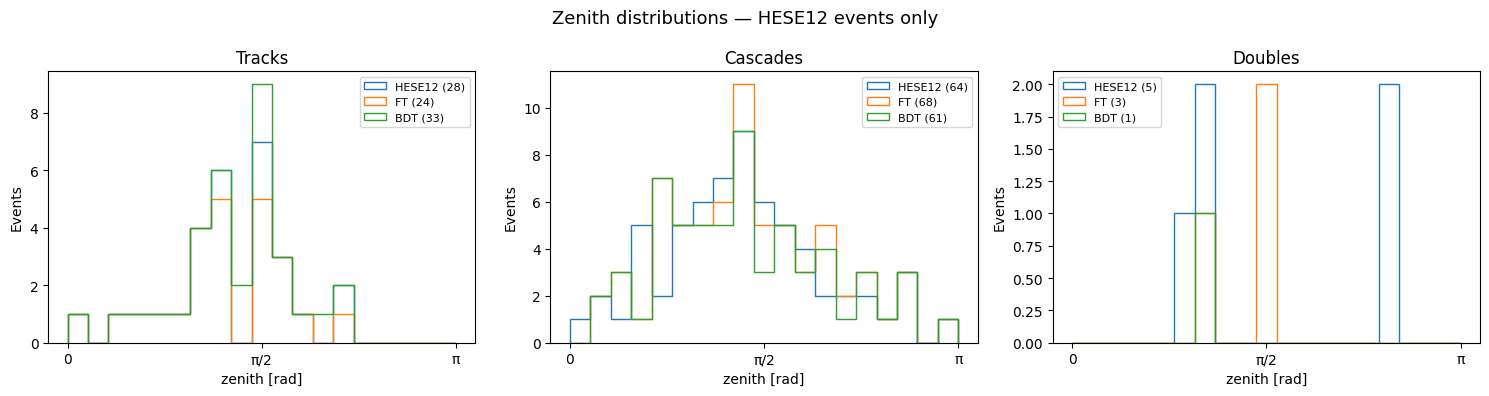

In [40]:
ft_casc_h12   = ft_casc[ft_casc.index.isin(h12_all)]
ft_double_h12 = ft_double[ft_double.index.isin(h12_all)]
bdt_casc_h12  = bdt_casc[bdt_casc.index.isin(h12_all)]
bdt_double_h12 = bdt_double[bdt_double.index.isin(h12_all)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
topo_data = [
    ('Tracks',   hese12_track,  ft_track_h12,  bdt_track_h12),
    ('Cascades', hese12_casc,   ft_casc_h12,   bdt_casc_h12),
    ('Doubles',  hese12_double, ft_double_h12, bdt_double_h12),
]
for ax, (title, h12_df, ft_df, bdt_df) in zip(axes, topo_data):
    ax.hist(h12_df['reco_dir'],  bins=bins_zen, histtype='step', lw=2, label=f'HESE12 ({len(h12_df)})')
    ax.hist(ft_df['reco_dir'],   bins=bins_zen, histtype='step', lw=2, label=f'FT ({len(ft_df)})')
    ax.hist(bdt_df['reco_dir'],  bins=bins_zen, histtype='step', lw=2, label=f'BDT ({len(bdt_df)})')
    ax.set_xlabel('zenith [rad]')
    ax.set_ylabel('Events')
    ax.set_title(title)
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π'])
    ax.legend(fontsize=8)
fig.suptitle('Zenith distributions — HESE12 events only', fontsize=13)
plt.tight_layout()
plt.savefig('all_topo_zenith_comparison.pdf', bbox_inches='tight')
plt.show()

## Zenith distributions — tracks (all events, including non-HESE12)

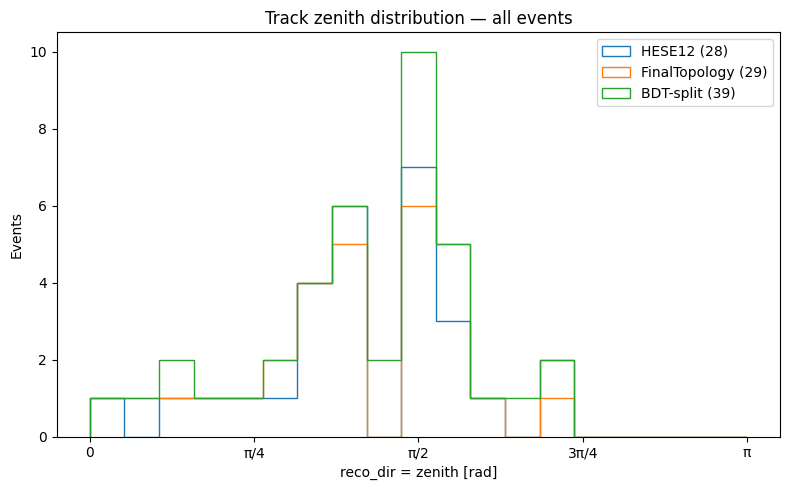

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(hese12_track['reco_dir'], bins=bins_zen, histtype='step', lw=2, label=f'HESE12 ({len(hese12_track)})')
ax.hist(ft_track['reco_dir'],     bins=bins_zen, histtype='step', lw=2, label=f'FinalTopology ({len(ft_track)})')
ax.hist(bdt_track['reco_dir'],    bins=bins_zen, histtype='step', lw=2, label=f'BDT-split ({len(bdt_track)})')
ax.set_xlabel('reco_dir = zenith [rad]')
ax.set_ylabel('Events')
ax.set_title('Track zenith distribution — all events')
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels(['0', 'π/4', 'π/2', '3π/4', 'π'])
ax.legend()
plt.tight_layout()
plt.savefig('track_zenith_all_events.pdf', bbox_inches='tight')
plt.show()

## Zenith distributions — all topologies (all events)

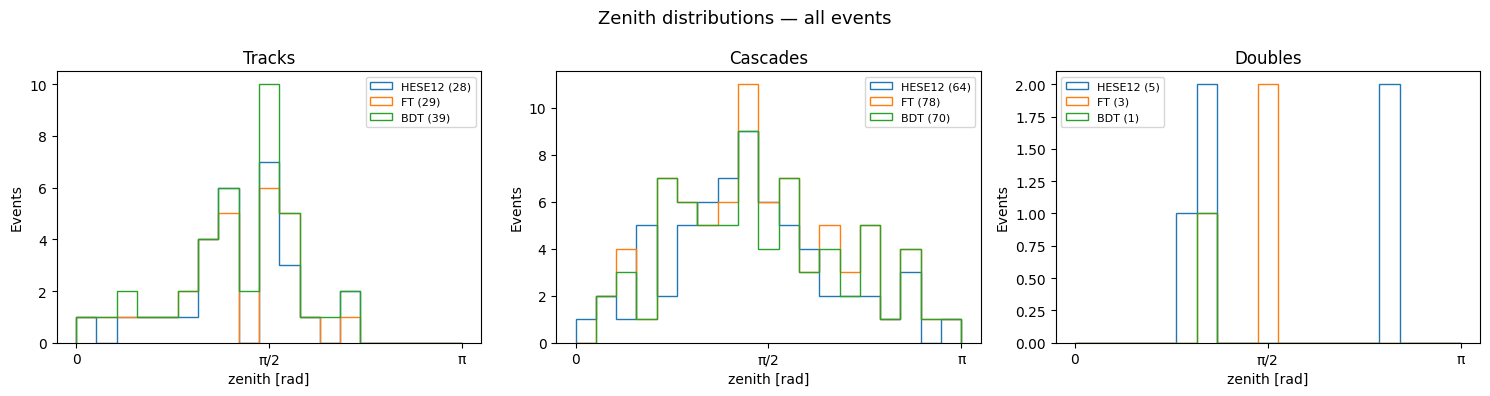

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
topo_data_all = [
    ('Tracks',   hese12_track,  ft_track,  bdt_track),
    ('Cascades', hese12_casc,   ft_casc,   bdt_casc),
    ('Doubles',  hese12_double, ft_double, bdt_double),
]
for ax, (title, h12_df, ft_df, bdt_df) in zip(axes, topo_data_all):
    ax.hist(h12_df['reco_dir'], bins=bins_zen, histtype='step', lw=2, label=f'HESE12 ({len(h12_df)})')
    ax.hist(ft_df['reco_dir'],  bins=bins_zen, histtype='step', lw=2, label=f'FT ({len(ft_df)})')
    ax.hist(bdt_df['reco_dir'], bins=bins_zen, histtype='step', lw=2, label=f'BDT ({len(bdt_df)})')
    ax.set_xlabel('zenith [rad]')
    ax.set_ylabel('Events')
    ax.set_title(title)
    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π'])
    ax.legend(fontsize=8)
fig.suptitle('Zenith distributions — all events', fontsize=13)
plt.tight_layout()
plt.savefig('all_topo_zenith_all_events.pdf', bbox_inches='tight')
plt.show()